# Downside-Beta -- do stocks that crash *with* the market pay you more? 📉
### Ang, Chen & Xing (2006), tested honestly -- and asked the one question that decides it

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Distinct from beta%3F: Not_supported](https://img.shields.io/badge/Distinct_from_beta%3F-Not_supported-8b949e?style=flat-square)

A famous 2006 paper found that stocks whose price falls *hardest when the whole market falls* -- high **downside beta** -- go on to earn more, about **6% a year** extra. The idea is intuitive: a stock that abandons you exactly when everything else is sinking is a lousy hedge, so you should be paid to hold it. This notebook asks two things in plain language: is that premium real on today's tape, and -- the question that actually decides it -- is it anything more than the ordinary reward for holding *risky* (high-beta) stocks?

> This is the plain-language layer. The downside-beta maths, the HAC *t*-stats, the beta control and the cost sweep live in the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Reproducible research: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

from downside_beta import data, strategy as st

# --- the real tape is cache-first; fall back to the synthetic control offline ---
HAVE_REAL = os.path.exists(data.PANEL_CACHE) and os.path.exists(data.MARKET_CACHE)
if HAVE_REAL:
    try:
        rdf_real, mkt_real = data.load_real(fetch=False)
        # drop the in-progress month
        last = rdf_real.index[-1]
        cut = pd.Timestamp(last.year, last.month, 1) - pd.Timedelta(days=1)
        rdf_real, mkt_real = rdf_real.loc[:cut], mkt_real.loc[:cut]
        print(f"REAL tape: {rdf_real.shape[0]} days x {rdf_real.shape[1]} tickers, "
              f"{rdf_real.index[0].date()} -> {rdf_real.index[-1].date()}")
    except Exception as e:
        HAVE_REAL = False
        print("Real cache unreadable, falling back to synthetic:", e)
if not HAVE_REAL:
    print("No real cache -- notebook will run on the SYNTHETIC tape and quote frozen "
          "real numbers from docs/results.md.")


REAL tape: 5384 days x 40 tickers, 2005-01-04 -> 2026-05-29


## The answer first 🎯

| Question | Answer |
|---|---|
| Do high downside-beta stocks earn more? | **On the raw sort, yes** -- about +12%/yr (HAC *t* = +2.56) on our tape. |
| Is it a *downside* story, or just a *beta* story? | **Just beta.** A plain-beta sort earns nearly the same (+10%/yr), and the part of downside beta that beta *doesn't* explain earns **-0.5%/yr** (*t* = -0.14) -- nothing. |
| Could you trade it? | **No.** At 10 bps costs the spread slips below the significance bar, and what's left is plain market exposure you can buy cheaper. |

So: a real-looking number that is really the oldest premium in finance (beta) wearing a downside costume.

## 1 · The claim

Ordinary finance measures a stock's risk by its **beta**: how much it moves when the market moves, up *or* down, treated the same. Ang, Chen & Xing argued that investors don't feel up and down the same way -- losing money when *everything* is crashing hurts far more than missing out on a rally. So they split beta in two:

- **Downside beta (β⁻)** -- how much a stock moves on days the market is *down*.
- **Upside beta (β⁺)** -- how much it moves on days the market is *up*.

Their finding: stocks with high β⁻ earn a premium of roughly **6% per year** over low-β⁻ stocks, and -- the strong claim -- this is *not* just the ordinary beta premium in disguise.

## 2 · So what?

If true, it's a genuinely new risk factor: a way to earn extra return by deliberately holding the stocks that hurt most in crashes -- and a reason the plain CAPM mis-prices the cross-section. If *false* -- if β⁻ only pays because high-β⁻ stocks are just high-β stocks -- then the 'downside premium' is a relabelling of something we've known since 1964, and you'd be paying turnover and shorting costs to harvest market beta the hard way.

## 3 · How would we even know?

The test is a sort. Each month, rank every stock by its trailing downside beta, buy the top fifth, short the bottom fifth, hold a month, repeat. If the long-short earns a positive, statistically real return, the premium exists.

**The trap, announced in advance:** high-β⁻ stocks are usually just high-β stocks. So we run the *exact same sort on plain beta* as a control, and -- the decisive test -- we sort on **relative downside beta** (β⁻ minus β), the part of downside risk that ordinary beta does *not* explain. If that earns nothing, the downside story is busted, however good the raw number looks.

## 4 · The teardown -- let's actually look

First, a sanity check on a **synthetic market we built ourselves**, where we *know* the answer. We plant a real downside premium in one tape and none in another, and confirm our sorting machine finds it only where it exists. Then we turn the same machine on the real tape.

In [2]:
# --- machinery proof on the SYNTHETIC tape (we know the truth here) ---
rdf_null, mkt_null, _ = data.synthetic_panel(downside_premium=0.0, seed=332)
rdf_pos,  mkt_pos,  _ = data.synthetic_panel(downside_premium=0.0025, seed=332)
res_null = st.monthly_quantile_returns(rdf_null, mkt_null, signal_col='beta_dn')
res_pos  = st.monthly_quantile_returns(rdf_pos,  mkt_pos,  signal_col='beta_dn')
s_null = st.summarize(res_null['spread']); s_pos = st.summarize(res_pos['spread'])
print(f"SYNTHETIC null   : spread {s_null['mean_ann']*100:6.1f}%/yr  t={s_null['tstat']:+.2f}")
print(f"SYNTHETIC priced : spread {s_pos['mean_ann']*100:6.1f}%/yr  t={s_pos['tstat']:+.2f}")
print('The machine finds the premium only when we plant one. Good.')

SYNTHETIC null   : spread   -8.4%/yr  t=-0.85
SYNTHETIC priced : spread   30.0%/yr  t=+2.87
The machine finds the premium only when we plant one. Good.


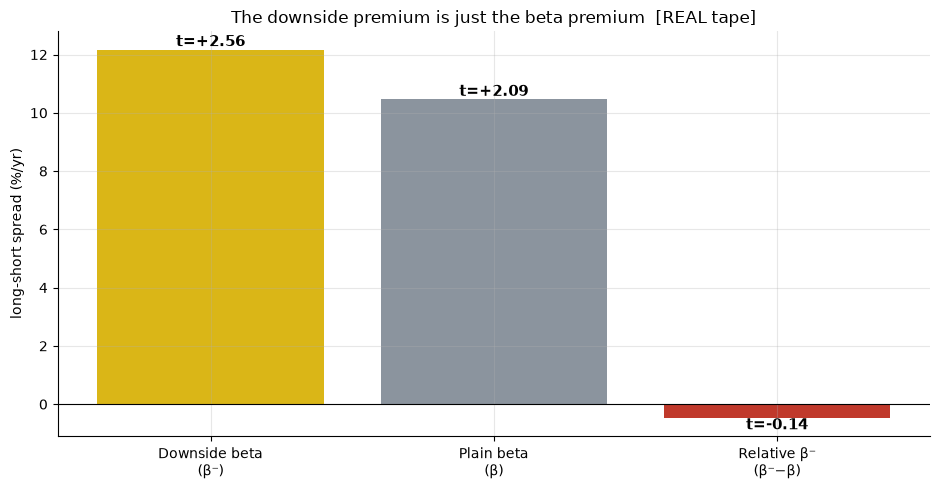

[REAL]  beta_dn +12.2%/yr (t=+2.56) | beta +10.5%/yr (t=+2.09) | rel_dbeta -0.5%/yr (t=-0.14)


In [3]:
# --- the real question: raw beta_dn sort vs the beta control (REAL tape if cached) ---
if HAVE_REAL:
    tape = 'REAL'
    rr = {c: st.summarize(st.monthly_quantile_returns(rdf_real, mkt_real, signal_col=c, min_stocks=8)['spread'])
          for c in ['beta_dn','beta','rel_dbeta']}
    dbeta_ann, dbeta_t = rr['beta_dn']['mean_ann']*100, rr['beta_dn']['tstat']
    beta_ann,  beta_t  = rr['beta']['mean_ann']*100,    rr['beta']['tstat']
    reldb_ann, reldb_t = rr['rel_dbeta']['mean_ann']*100, rr['rel_dbeta']['tstat']
else:
    tape = 'FROZEN (docs/results.md)'
    dbeta_ann, dbeta_t = 12.17, 2.56
    beta_ann,  beta_t  = 10.46, 2.09
    reldb_ann, reldb_t = -0.46, -0.14
labels = ['Downside beta\n(β⁻)', 'Plain beta\n(β)', 'Relative β⁻\n(β⁻−β)']
vals = [dbeta_ann, beta_ann, reldb_ann]; ts = [dbeta_t, beta_t, reldb_t]
cols = [AMBER, GREY, RED]
fig, ax = plt.subplots()
bars = ax.bar(labels, vals, color=cols)
for b, t in zip(bars, ts):
    ax.text(b.get_x()+b.get_width()/2, b.get_height(), f't={t:+.2f}', ha='center',
            va='bottom' if b.get_height()>=0 else 'top', fontsize=11, fontweight='bold')
ax.axhline(0, color='k', lw=.8)
ax.set_ylabel('long-short spread (%/yr)')
ax.set_title(f'The downside premium is just the beta premium  [{tape} tape]')
plt.tight_layout(); plt.show()
print(f'[{tape}]  beta_dn {dbeta_ann:+.1f}%/yr (t={dbeta_t:+.2f}) | '
      f'beta {beta_ann:+.1f}%/yr (t={beta_t:+.2f}) | rel_dbeta {reldb_ann:+.1f}%/yr (t={reldb_t:+.2f})')

The picture says it all. The raw downside-beta sort (amber) looks like a real premium. The plain-beta sort (grey) earns almost exactly the same. And the *relative* downside beta (red) -- the part that would make this a genuinely new factor -- earns **nothing**. The premium is beta, relabelled.

## 5 · The verdict

- **Signal -- MIXED.** The raw β⁻ spread is statistically real on this tape (+12%/yr, *t* = +2.56). The *downside-specific* part is not (-0.5%/yr, *t* = -0.14). Real on the raw sort, none on the downside story.
- **Distinct from plain beta? -- NOT SUPPORTED.** The whole premium survives in the beta sort and vanishes once beta is removed.
- **Tradability -- MIRAGE.** It dies under realistic costs, and the part that doesn't is market beta you can buy far more cheaply.

## 6 · Could you actually trade it?

Even the *raw* (beta-flavoured) spread is a heavy monthly long-short: you rebalance both legs every month, and the short leg is high-beta names that cost the most to borrow. Here's what plausible trading costs do to it.

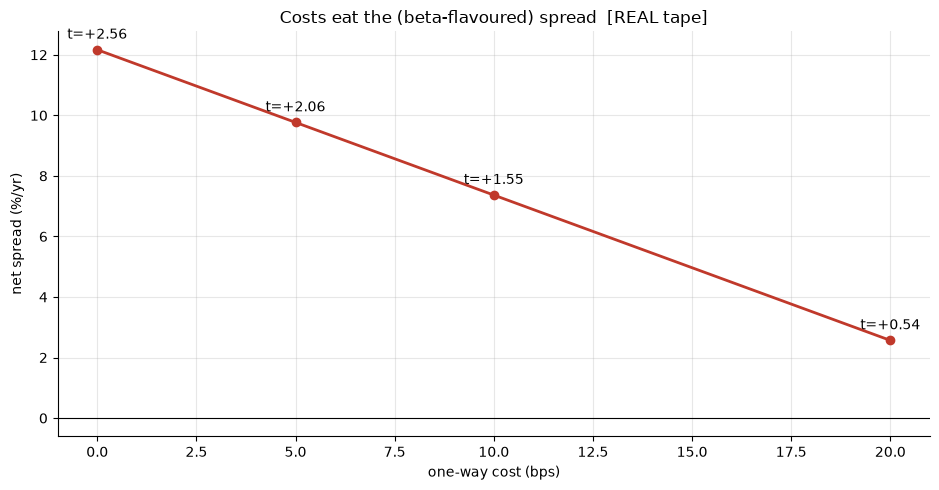

[REAL] net spread by cost (bps): {0: 12.2, 5: 9.8, 10: 7.4, 20: 2.6}


In [4]:
costs = [0, 5, 10, 20]
if HAVE_REAL:
    res = st.monthly_quantile_returns(rdf_real, mkt_real, signal_col='beta_dn', min_stocks=8)
    net_ann = [st.summarize(st.net_spread(res, one_way_bps=c))['mean_ann']*100 for c in costs]
    net_t   = [st.summarize(st.net_spread(res, one_way_bps=c))['tstat'] for c in costs]
    tape = 'REAL'
else:
    net_ann = [12.17, 9.77, 7.37, 2.57]
    net_t   = [2.56, 2.06, 1.55, 0.54]
    tape = 'FROZEN'
fig, ax = plt.subplots()
ax.plot(costs, net_ann, 'o-', color=RED, lw=2)
for c, a, t in zip(costs, net_ann, net_t):
    ax.annotate(f't={t:+.2f}', (c, a), textcoords='offset points', xytext=(0,8), ha='center')
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('net spread (%/yr)')
ax.set_title(f'Costs eat the (beta-flavoured) spread  [{tape} tape]')
ax.axhline(0, color='k', lw=.8)
plt.tight_layout(); plt.show()
print(f'[{tape}] net spread by cost (bps):', dict(zip(costs, [round(a,1) for a in net_ann])))

## 7 · Going further 🚪

- **Broaden the universe.** Our basket is 40 survivors; the original paper used the full CRSP cross-section. A wider, survivorship-free panel might revive a small *incremental* premium -- or kill it further.
- **Coskewness.** Harvey-Siddique (2000) argue the priced thing is *coskewness* (crashing with the market), a close cousin -- worth running side by side.
- **The mirror.** Betting-Against-Beta (Study 238) says *low* beta is what pays. Two famous papers, opposite tilts, same beta machinery -- fork this and race them.